<a href="https://colab.research.google.com/github/ovirce/360004---AI---SA2-Part-A---Code/blob/main/360004_AI_SA2_Part_A_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [371]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [372]:
#import the dataset
data = pd.read_csv('tested.csv')
#Exploratory Data Analysis
print("First 5 Rows", data.head())
print("Dataset Information", data.info())
print("Statistical Summary", data.describe())

First 5 Rows    PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
D

In [373]:
#locate missing values
print("Missing values:")
display(data.isnull().sum())

Missing values:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [374]:
#fill the missing values (Dan said to mabe make a predictive algorithm here for the high grade)
#feature engineering
data['Has_Cabin'] = data['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)
data['Family_Size'] = data['SibSp'] + data['Parch'] + 1
data['Fare_Per_Person'] = data['Fare'] / data['Family_Size']
#data['Fare_Per_Person'].fillna(data['Fare_Per_Person'].median(), inplace=True) #fill in the fare per person missing values with the median

impute = IterativeImputer(estimator=RandomForestRegressor(random_state=42), max_iter=10)
imputeColumns = ['Age', 'Fare', 'Fare_Per_Person']
data[imputeColumns] = impute.fit_transform(data[imputeColumns])

#data['Age'].fillna(data['Age'].median(), inplace=True) #fill in the age missing values with the mean of age
data['Cabin'].fillna(data['Cabin'].mode()[0], inplace=True) #fill in the cabin missing values with the mode of cabin
#data['Fare'].fillna(data['Fare'].mean(), inplace=True) #fill in the fare missing values with the mean of fare

# 2. Embarked: Fill the 2 missing values with the most common port ('S')
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

#data = data.drop(['PassengerId', 'Name', 'Cabin'], axis=1)

/tmp/ipykernel_849/2303735163.py:13: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [375]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


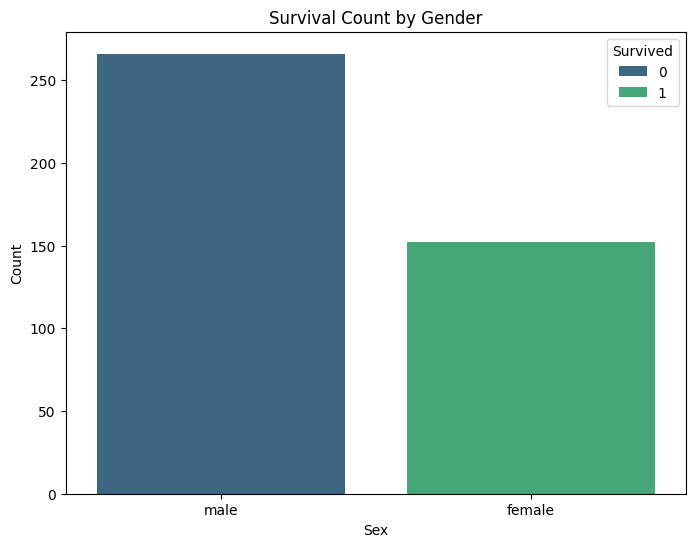

In [376]:
#categorical
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x='Sex', hue='Survived', palette='viridis')
plt.title('Survival Count by Gender')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

In [377]:
port_mapping = {
    'S': {'Port_Name': 'Southampton', 'Lat': 50.897, 'Lon': -1.404},
    'C': {'Port_Name': 'Cherbourg', 'Lat': 49.630, 'Lon': -1.620},
    'Q': {'Port_Name': 'Queenstown', 'Lat': 51.850, 'Lon': -8.294}
}

spatial_data = data.copy()
spatial_data = spatial_data.dropna(subset=['Embarked']) # Drop the 2 missing ones just for the map

spatial_data['Port_Name'] = spatial_data['Embarked'].map(lambda x: port_mapping[x]['Port_Name'])
spatial_data['Lat'] = spatial_data['Embarked'].map(lambda x: port_mapping[x]['Lat'])
spatial_data['Lon'] = spatial_data['Embarked'].map(lambda x: port_mapping[x]['Lon'])

port_stats = spatial_data.groupby(['Port_Name', 'Lat', 'Lon']).agg(
    Total_Passengers=('PassengerId', 'count'),
    Survival_Rate=('Survived', 'mean')
).reset_index()

port_stats['Survival_Rate'] = (port_stats['Survival_Rate'] * 100).round(1)

fig = px.scatter_geo(
    port_stats,
    lat='Lat',
    lon='Lon',
    size='Total_Passengers',
    color='Survival_Rate',
    hover_name='Port_Name',
    hover_data={'Lat': False, 'Lon': False, 'Total_Passengers': True, 'Survival_Rate': True},
    title="Spatial Analysis: Passenger Volume and Survival Rate by Port",
    color_continuous_scale="Viridis",
    projection="natural earth"
)
fig.update_geos(
    resolution=50,
    showcoastlines=True, coastlinecolor="RebeccaPurple",
    showland=True, landcolor="LightGreen",
    showocean=True, oceancolor="LightBlue",
    showcountries=True,
    lataxis_range=[40, 60], lonaxis_range=[-15, 10]
)

fig.show()



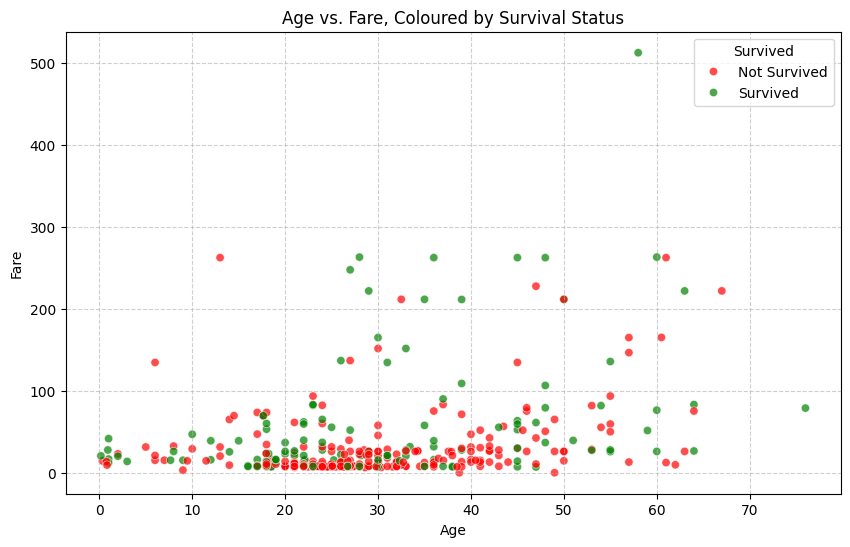

In [378]:
#relational
plt.figure(figsize=(10, 6))
custom_palette = {0: 'red', 1: 'green'}

sns.scatterplot(data=data, x='Age', y='Fare', hue='Survived', palette=custom_palette, alpha=0.7)
plt.title('Age vs. Fare, Coloured by Survival Status')
plt.xlabel('Age')
plt.ylabel('Fare')
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = ['Not Survived', 'Survived']
plt.legend(handles=handles, labels=new_labels, title='Survived', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

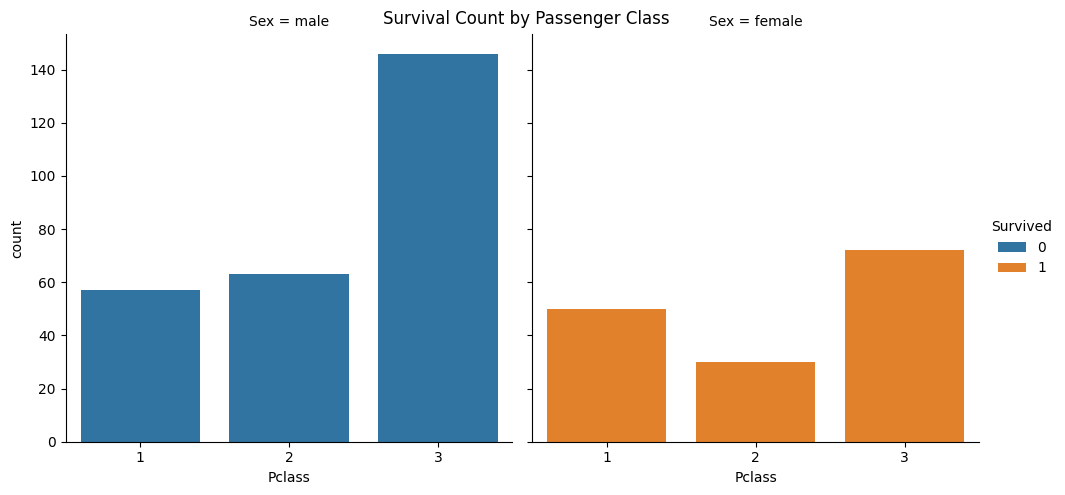

In [379]:
#hierarchical graph
sns.catplot(x='Pclass', hue='Survived', data = data, kind = 'count', col='Sex')
plt.suptitle('Survival Count by Passenger Class')
plt.show()


In [380]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# prepare data
# 3. ENCODE TEXT TO NUMBERS
le = LabelEncoder()
data['Sex'] = le.fit_transform(data['Sex'])
data['Embarked'] = le.fit_transform(data['Embarked'])


# We use Fare, Age, Sex, Survived, and Embarked to guess their Class.
features = ['Fare', 'Fare_Per_Person', 'Age', 'Sex', 'Survived', 'Embarked', 'Has_Cabin', 'Family_Size']
X = data[features]

#'y'is now what we are trying to predict: Pclass (1, 2, or 3)
y = data['Pclass']

#TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# It will test every single combination of these numbers.
param_grid = {
    'n_estimators': [50, 100, 200], # How many trees in the forest?
    'max_depth': [5, 8, 10]         # How deep can the trees grow?
}

# Set up the GridSearch to test our options using 3-Fold Cross Validation
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3)

# Let the GridSearch run and find the best model
grid_search.fit(X_train, y_train)

# Grab the winning model from the Grid Search
best_model = grid_search.best_estimator_

print(f"The best settings found were: {grid_search.best_params_}")

The best settings found were: {'max_depth': 10, 'n_estimators': 50}


In [381]:
model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=2, random_state=42)
model.fit(X_train, y_train)
#train model
predictions = model.predict(X_test)

Final Accuracy: 0.9524
Classification Report
              precision    recall  f1-score   support

           1       0.95      1.00      0.98        21
           2       0.91      0.95      0.93        21
           3       0.97      0.93      0.95        42

    accuracy                           0.95        84
   macro avg       0.95      0.96      0.95        84
weighted avg       0.95      0.95      0.95        84

Confusion Matrix
[[21  0  0]
 [ 0 20  1]
 [ 1  2 39]]
Training accuracy: 0.9731
Testing accuracy: 0.9524


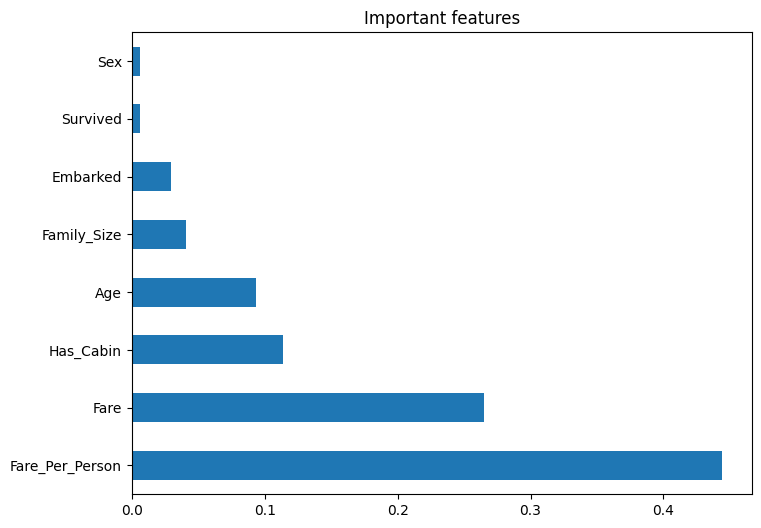

In [382]:
#evaluation
accuracy = accuracy_score(y_test, predictions)
print(f"Final Accuracy: {accuracy:.4f}")

print("Classification Report")
print(classification_report(y_test, predictions))

print("Confusion Matrix")
print(confusion_matrix(y_test, predictions))

print(f"Training accuracy: {model.score(X_train, y_train):.4f}")
print(f"Testing accuracy: {model.score(X_test, y_test):.4f}")

#feature importance
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind='barh', figsize=(8,6))
plt.title("Important features")
plt.show()